# 03 · Run the active-learning mode-shape loop ON THE INSTRUMENT

Drives an Asylum/Cypher system through Igor Pro to reconstruct the contact-resonance
mode shape from the **minimum number of laser positions**, choosing each position by
active learning and stopping when the displacement null spot (D-NS) is pinned.

**Windows / Igor only.** Requires `win32com` and `igor2`.

### Coordinates — read this once
`x = 0` is the **clamped base** and x increases toward the **free end**. The whole
package assumes this (`VirtualInstrument.measure_at`, and
`lowrank._signed_zero_crossing`, which resolves the null to the largest x as "nearest
the free end"), so do not flip it. Instead say where the laser is *parked* with
`START_AT`, and set `x_grid` to the part of the beam you can actually reach.

A D-NS of 212.3 µm on a 220 µm probe means 7.7 µm in from the free end —
`inst.um_from_free_end()` does the conversion, and the CSV log records both.

### Before you run — set up in Igor (once)
1. Approach and find the contact resonance at your chosen load.
2. **Set a FIXED tune range** bracketing **one** eigenmode's resonance *and* its
   antiresonance. No resonance tracking / auto-recenter — every position must be tuned
   over the *same* window.
3. **Check the resolution.** You need ≥6 points across the resonance FWHM. Igor's step
   is span/points, so 330–470 kHz at 992 points = 141 Hz ≈ 11 points across a 1.6 kHz
   FWHM. A 25 kHz–1.8 MHz span at 1984 points is 882 Hz ≈ 2 points — far too coarse.
   Also make the per-point dwell comfortably longer than the ring-down time
   `Q / (π f₀)` (≈ 0.2 ms at Q 240 / 390 kHz) or the peak comes out skewed.
4. **Park the detection laser where `START_AT` says**, and run the `preview_moves()`
   cell below to confirm the moves go *into* the cantilever before you engage.
5. Make sure the save folder exists and the base filename is set.

## 1 · Imports and connect to Igor

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import win32com.client
from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap import (LowRankModeMap, plot_state, dns_branch,
                           LiveModeMapPlot, dense_reference_sweep, compare_to_dense,
                           dense_grid)

# For a smoother live plot use the widget backend (pip install ipympl);
# the default inline backend works too, it just repaints the whole cell.
# %matplotlib widget

igor = win32com.client.Dispatch('IgorPro.Application')
print('Connected to Igor Pro')

Connected to Igor Pro


## 2 · Experiment parameters — edit these

In [2]:
# --- file locations (same convention as the dense-sweep notebook) ---
file_loc      = r'D:\User Data\Liam\ActiveModeMap\Demo4'   # must exist
base_filename = 'AMap'
log_filename  = os.path.join(file_loc, 'AMap_log')

# --- contact / drive ---
load_nN   = 1000      # applied load (nN)
dc_bias_V = 0.0       # DC bias on Output.A (single-domain D-NS map)

# --- frequency handling ---------------------------------------------------
# The map is ALWAYS reconstructed over the whole tune window, at every position:
# the low-rank fit is an independent least-squares solve at each frequency, so
# covering the full spectrum costs nothing and nothing is discarded. Both
# resonances, the antiresonance branch, and the off-resonance background all come
# out of the same fit.
#
# DNS_BAND_HZ only tells the null-spot estimator where to look, because its
# antiresonance search window is a fraction of the span it is handed -- give it
# 1.7 MHz and that search is meaningless. Set it around ONE mode; reprocess the
# saved tunes afterwards for the other one.
DNS_BAND_HZ    = (330e3, 470e3)     # locate the null using the ~387 kHz mode
tune_center_Hz = 387.5e3            # logging only

# --- geometry and the reachable span --------------------------------------
# x = 0 is the CLAMPED BASE; x increases toward the FREE END.
PROBE_L_UM = 225.0    # full cantilever length
START_AT   = 'free_end'   # where the laser is parked: 'free_end' or 'base'

# The span you can actually reach. On a stiff probe the base end is often
# inaccessible; just map the part you can reach and set x_grid to match — the
# Chebyshev basis is fitted over x_grid's own range, so restricting it keeps the
# reconstruction an interpolation. Do NOT set x_grid wider than what you measure:
# the low-rank model cannot extrapolate (see docs/SPAN_AND_SAMPLING.md).
REACH_UM   = 120.0    # how far in from the free end you can get
step_um    = 1.0
x_grid     = np.arange(PROBE_L_UM - REACH_UM, PROBE_L_UM + 1e-6, step_um)   # 100..220

# Which DoLDMove sign moves the spot toward the free end (+1 on this Cypher).
# Verify with preview_moves() below before engaging.
HW_SIGN_TOWARD_FREE_END = +1

# --- active-learning settings ---
# RANK is the knob that sets how few positions you need: the fit needs at least
# RANK positions to be determined at all, RANK+1 for any residual, and RANK+2 for
# a residual with 2 dof (the smallest honest default). Simulation and the Demo1
# data both put rank 4-5 at sub-micron D-NS accuracy; rank 3 is systematically
# ~3 um out while looking MORE stable, and rank 6+ overfits. Rank 4 makes 6
# positions a realistic floor -- see docs/RANK_AND_POSITIONS.md.
RANK          = 4       # spatial basis dimension (4 or 5; NOT 3)
MAX_POSITIONS = 20      # hard cap on positions actually measured
MIN_POSITIONS = 6       # = RANK + 2; fewer leaves too little residual for a real CI
DNS_CI_TOL_UM = 1.0     # stop once the D-NS 95% CI is below this
RECALIBRATE_EACH = True # AutoWedge + InvOLS at every position

os.makedirs(file_loc, exist_ok=True)
print(f'probe {PROBE_L_UM:.0f} um; mapping x = {x_grid[0]:.0f}-{x_grid[-1]:.0f} um '
      f'(0 = base), i.e. the {REACH_UM:.0f} um nearest the free end')

probe 225 um; mapping x = 105-225 um (0 = base), i.e. the 120 um nearest the free end


## 3 · Build the automation, the instrument adapter, and the loop manager

In [3]:
automation = AFMLaserSweepAutomation(igor, file_loc, base_filename, log_filename)
automation.eigenmode_center_freq = tune_center_Hz
automation.autowedge_pause = 15.0
automation.invols_bounds = (4e-8, 10e-7)
automation.resonance_band_Hz = DNS_BAND_HZ    # for the logged f_res / Q only

# analysis_band_Hz is left None on purpose: measure_at hands the FULL spectrum to
# the loop, and the band is applied downstream by LowRankModeMap(dns_band_Hz=...)
inst = AsylumInstrument(automation, load_nN=load_nN, dc_bias_V=dc_bias_V,
                        recalibrate_each=RECALIBRATE_EACH,
                        analysis_band_Hz=None,
                        start_at=START_AT, span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)

mm = LowRankModeMap(x_grid, freq_grid=None, rank=RANK,
                    seeds_um=[x_grid[0], x_grid[len(x_grid)//2], x_grid[-1]],
                    min_positions=MIN_POSITIONS, dns_ci_tol_um=DNS_CI_TOL_UM,
                    start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                    dns_band_Hz=DNS_BAND_HZ, stable_over=3)

# ---- CHECK THE DIRECTION BEFORE ENGAGING -------------------------------------
# Walking inward from the free end, every move should read "toward base".
# If they read "toward free end", flip HW_SIGN_TOWARD_FREE_END and re-run.
inst.preview_moves([mm.x_grid[i] for i in mm._order[:MAX_POSITIONS]])

start: x = 225.0 um (free end, 0.0 um from the free end)
  x = 0 is the clamped base; hw_sign_toward_free_end = +1
  x =   225.0 um   DoLDMove(    +0.0, 0)   no move
  x =   165.0 um   DoLDMove(   -60.0, 0)   toward base
  x =   105.0 um   DoLDMove(   -60.0, 0)   toward base
  x =   130.0 um   DoLDMove(   +25.0, 0)   toward free end
  x =   196.0 um   DoLDMove(   +66.0, 0)   toward free end
  x =   224.0 um   DoLDMove(   +28.0, 0)   toward free end
  x =   106.0 um   DoLDMove(  -118.0, 0)   toward base
  x =   136.0 um   DoLDMove(   +30.0, 0)   toward free end
  x =   193.0 um   DoLDMove(   +57.0, 0)   toward free end
  x =   138.0 um   DoLDMove(   -55.0, 0)   toward base
  x =   223.0 um   DoLDMove(   +85.0, 0)   toward free end
  x =   107.0 um   DoLDMove(  -116.0, 0)   toward base
  x =   192.0 um   DoLDMove(   +85.0, 0)   toward free end
  x =   139.0 um   DoLDMove(   -53.0, 0)   toward base
  x =   191.0 um   DoLDMove(   +52.0, 0)   toward free end
  x =   222.0 um   DoLDMove(   +

## 4 · Run the active-learning loop — live

Each iteration: pick the next position, drive the instrument (withdraw → move laser →
optical image → AutoWedge+InvOLS → engage → tune → read the complex spectrum →
withdraw), update the reconstruction, and redraw.

`LiveModeMapPlot` reuses a single figure and replaces the cell output each time, so you
watch one panel evolve instead of accumulating plots. The four panels are the
reconstructed map over the **whole** tune window, its uncertainty, the measured spectra
against the fit, and the D-NS convergence trace. A redraw is ~0.2 s against ~60 s per
position, so the display costs nothing.

Interrupt the cell at any time; whatever has been measured is retained in `mm` and
`inst.records`.

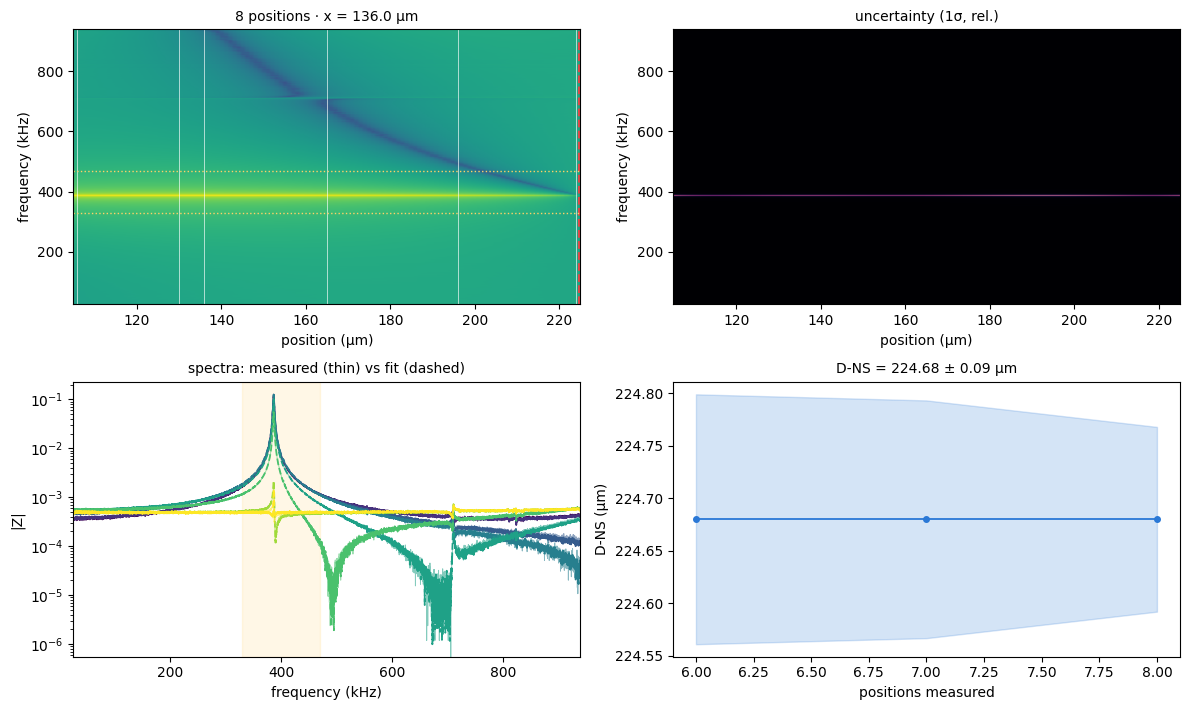

n= 8  x= 136.0 µm   D-NS 224.68 ± 0.09 µm (0.32 µm from the free end)   crossings [224.7]

Converged — CI below tolerance AND the estimate has stopped moving.

Loop done. Positions measured: 8


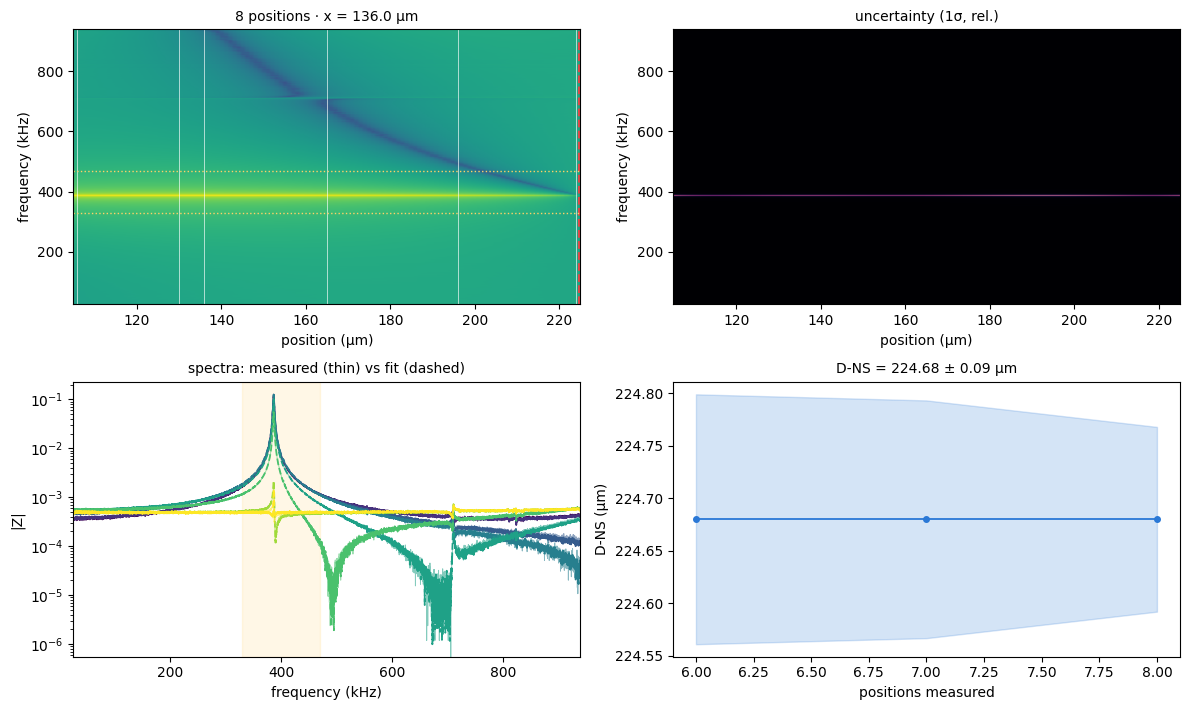

In [4]:
live = LiveModeMapPlot()
rec = None
for step in range(MAX_POSITIONS):
    x = mm.next_position()
    freq, Z, meta = inst.measure_at(x)

    # --- sanity check the spectrum BEFORE it enters the reconstruction ---
    if mm.n == 0:
        df = float(np.median(np.diff(freq)))
        print(f"tune window: {freq[0]/1e3:.1f}-{freq[-1]/1e3:.1f} kHz, "
              f"{freq.size} points, {df:.0f} Hz step")
        ipk = int(np.argmax(np.abs(Z)))
        print(f"strongest response: {freq[ipk]/1e3:.2f} kHz")
        assert freq.size >= 32, 'truncated spectrum — do not proceed'
        lo, hi = DNS_BAND_HZ
        assert (freq >= lo).any() and (freq <= hi).any(), \
            'DNS_BAND_HZ does not overlap the tune window'

    mm.add_measurement(x, freq, Z)
    if mm.n >= mm.min_positions:
        rec = mm.reconstruct(nboot=150)
        live.update(mm, rec, title=f'{mm.n} positions · x = {x:.1f} µm')
        xc = rec['crossings']
        print(f"n={mm.n:2d}  x={x:6.1f} µm   "
              f"D-NS {rec['dns']:.2f} ± {rec['dns_ci']/2:.2f} µm "
              f"({inst.um_from_free_end(rec['dns']):.2f} µm from the free end)   "
              f"crossings {np.round(xc, 1)}")
        if mm.converged():
            print('\nConverged — CI below tolerance AND the estimate has stopped moving.')
            break
    else:
        print(f"n={mm.n:2d}  x={x:6.1f} µm   (need {mm.min_positions} before fitting)")

inst.close()   # withdraw + zero DC bias
print('\nLoop done. Positions measured:', mm.n)

## 5 · Final reconstruction and save

saved ActiveModeMap_result.png / .npz  and ActiveModeMap_log.csv
reconstructed map: 121 positions x 8367 frequencies, 25.0-940.0 kHz
D-NS = 224.68 ± 0.09 µm  = 0.32 µm from the free end   (from 8 positions)

  D-NS vs rank (8 positions):
    rank 3:   224.19 um
    rank 4:   224.68 um
    rank 5:   225.00 um
  median 224.68 um, spread across neighbouring ranks 0.81 um
  ^ use that spread, not the bootstrap CI, as the uncertainty you quote


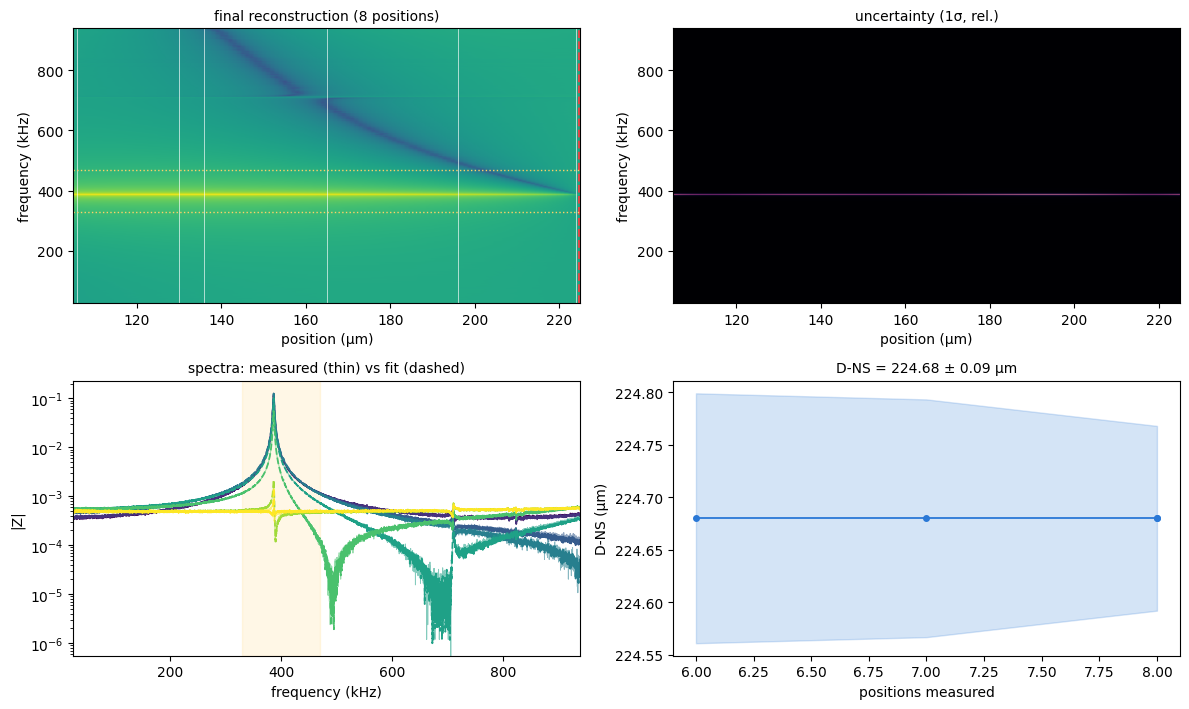

In [5]:
rec = mm.reconstruct(nboot=400)
ax = plot_state(mm, rec, title=f'final reconstruction ({mm.n} positions)')
fig = ax.ravel()[0].figure
fig.savefig(os.path.join(file_loc, 'ActiveModeMap_result.png'), dpi=150, bbox_inches='tight')

# save the FULL reconstructed spectrum at every grid position, the raw measured
# spectra, and the per-position log
sel = rec['sel_idx']
np.savez(os.path.join(file_loc, 'ActiveModeMap_result.npz'),
         x_grid=mm.x_grid, freq=mm.freq, Zrec=rec['Zrec'], std=rec['std'],
         measured_x=mm.x_grid[sel], measured_Z=rec['Zsel'],
         dns=rec['dns'], dns_ci=rec['dns_ci'], dns_samples=rec['dns_samples'],
         crossings=rec['crossings'], fa=rec['fa'], ires=rec['ires'],
         dns_band_Hz=np.asarray(DNS_BAND_HZ, float),
         probe_L_um=PROBE_L_UM, um_from_free_end=PROBE_L_UM - rec['dns'])
log_path = inst.save_log()
print(f"saved ActiveModeMap_result.png / .npz  and {os.path.basename(log_path)}")
print(f"reconstructed map: {rec['Zrec'].shape[0]} positions x {rec['Zrec'].shape[1]} "
      f"frequencies, {mm.freq[0]/1e3:.1f}-{mm.freq[-1]/1e3:.1f} kHz")
print(f"D-NS = {rec['dns']:.2f} ± {rec['dns_ci']/2:.2f} µm  "
      f"= {PROBE_L_UM - rec['dns']:.2f} µm from the free end   "
      f"(from {mm.n} positions)")
if len(rec['crossings']) > 1:
    print(f"branch crossings: {np.round(rec['crossings'], 1)} µm — more than one null")

# The bootstrap CI only propagates noise through a fit whose rank is assumed
# correct, so it is blind to the dominant error: the choice of rank. Re-fitting
# the same data at neighbouring ranks costs nothing and is far more honest.
print()
sens = mm.rank_sensitivity()

## 5b · Resuming after an interruption, or after updating the library

Two things make a naive "just re-run the cell" fail:

1. **Python caches modules.** Editing `activemodemap/*.py` on disk does nothing to a
   kernel that already imported it. Re-running a cell re-runs the *old* code.
2. **Restarting the kernel loses `inst`.** The laser position is tracked in software,
   so a restart throws away the only record of where the spot is — and a fresh
   instrument that assumes `start_at` will be wrong by however far the run wandered.

So prefer **path A**, which reloads the module without losing the instrument. Use
path B only if the kernel is already gone.

In [6]:
# ============================================================================
# PATH A — library updated, kernel still alive (PREFERRED)
# Reloads the module and rebinds the names. `inst` survives, so the tracked laser
# position is kept, and `mm` / `rec` are untouched. Then just re-run the cells you
# need. Costs no microscope time.
# ============================================================================
import importlib
import activemodemap.online, activemodemap.lowrank, activemodemap.asylum
for _m in (activemodemap.lowrank, activemodemap.online, activemodemap.asylum):
    importlib.reload(_m)
from activemodemap.online import (dense_reference_sweep, compare_to_dense,
                                  dense_grid, plot_state, LiveModeMapPlot)
from activemodemap.lowrank import dns_branch

print(f'reloaded. inst still tracks x = {inst.current_x:.1f} um; mm has {mm.n} positions')
print('note: mm and inst are still instances of the OLD classes, so their *methods*')
print('are the old ones. That is fine for re-running the dense sweep (a module-level')
print('function), but if a fix touched LowRankModeMap or AsylumInstrument behaviour')
print('you need path B.')

reloaded. inst still tracks x = 136.0 um; mm has 8 positions
note: mm and inst are still instances of the OLD classes, so their *methods*
are the old ones. That is fine for re-running the dense sweep (a module-level
function), but if a fix touched LowRankModeMap or AsylumInstrument behaviour
you need path B.


In [7]:
# ============================================================================
# PATH B — kernel was restarted. Rebuild without going back on the microscope.
# Run cells 1-3 first (imports, parameters, automation), then this INSTEAD of the
# acquisition loop. Skip it entirely if you used path A.
# ============================================================================
REBUILD_FROM_DISK = False        # set True to use this path

if REBUILD_FROM_DISK:
    # --- 1. where is the laser, really? -------------------------------------
    # Software tracking is gone. Take the last position printed before the
    # interruption, CONFIRM IT OPTICALLY, and put it here. Getting this wrong
    # offsets every later move.
    LASER_IS_AT_UM = 224.0       # <-- EDIT ME, then verify with the video panel

    inst = AsylumInstrument(automation, load_nN=load_nN, dc_bias_V=dc_bias_V,
                            recalibrate_each=RECALIBRATE_EACH,
                            analysis_band_Hz=None,
                            x_start_um=LASER_IS_AT_UM,      # overrides start_at
                            span_um=PROBE_L_UM,
                            x_limits_um=(x_grid[0], x_grid[-1]),
                            hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)
    print(f'instrument rebuilt, laser declared at x = {inst.current_x:.1f} um '
          f'({inst.um_from_free_end(inst.current_x):.1f} um from the free end)')

    # --- 2. rebuild the reconstruction from the saved result ----------------
    # ActiveModeMap_result.npz stores the measured spectra and their frequency
    # axis, so the active-learning result is recoverable exactly, with no
    # re-measuring. (scripts/reprocess_tune_folder.py does the same from the raw
    # Tune_*.txt files if the npz is missing.)
    _d = np.load(os.path.join(file_loc, 'ActiveModeMap_result.npz'))
    mm = LowRankModeMap(x_grid, freq_grid=None, rank=RANK,
                        seeds_um=[x_grid[0], x_grid[len(x_grid)//2], x_grid[-1]],
                        min_positions=MIN_POSITIONS, dns_ci_tol_um=DNS_CI_TOL_UM,
                        start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                        dns_band_Hz=DNS_BAND_HZ, stable_over=3)
    for _x, _z in zip(_d['measured_x'], _d['measured_Z']):
        mm.add_measurement(float(_x), _d['freq'], _z)
    rec = mm.reconstruct(nboot=400)
    print(f'rebuilt mm from disk: {mm.n} positions, D-NS {rec["dns"]:.2f} um '
          f'(saved value was {float(_d["dns"]):.2f} um)')
    assert abs(rec['dns'] - float(_d['dns'])) < 0.5, 'rebuild disagrees with the saved result'
else:
    print('skipped (REBUILD_FROM_DISK is False)')

skipped (REBUILD_FROM_DISK is False)


## 6 · Dense reference sweep — the ground truth

Measures **every** position on a uniform grid, with no reconstruction and no
low-rank assumption: this *is* the map, and it is what the sparse result should be
judged against.

**The laser is moved back to the free end first.** This matters more than it looks.
Position is tracked in software from relative `DoLDMove` calls, so an instrument
object only knows where the spot is if it did every move itself. The active-learning
loop leaves the laser at whichever position it measured last (mid-span), so building
a *new* `AsylumInstrument` with `start_at='free_end'` would simply assert
`current_x = 225` while the spot sat at, say, 138 µm — and every dense move would
inherit that 87 µm offset. Asking for 225 → 107 would really traverse 138 → 20 and
run the spot off the base onto the chip, with the travel guard none the wiser
because it checks the *believed* position.

So the cell below reuses the same `inst` object, re-applies the DC bias that
`close()` zeroed, and calls `inst.move_to(x_park)` — one explicit, tracked,
limit-checked move, with an optical image so you can confirm the spot before
committing to a two-hour sweep.

The grid then starts at that parked position and walks inward at a constant pitch:
no wasted traverse, no direction reversals to accumulate backlash, and the sweep
progresses steadily across the beam because `dense_reference_sweep` measures in the
order given.

Budget roughly a minute per position — 1 µm over 118 µm is ~119 points, ~2 hours.
Interrupting is safe: whatever was measured is returned.

In [ ]:
DENSE_STEP_UM = 1.0     # uniform pitch; 1 um over a 118 um span is ~119 points

x_park = x_grid[-1] if START_AT == 'free_end' else x_grid[0]
x_far  = x_grid[0]  if START_AT == 'free_end' else x_grid[-1]

# Reuse the instrument from the loop: it is the only object that knows where the
# spot actually is. A fresh one would assume, and be wrong by however far the loop
# wandered. (If the kernel was restarted, see the note in the markdown above and
# re-sync deliberately with inst.set_position(<verified x>, confirm=True).)
print(f'laser is tracked at x = {inst.current_x:.1f} um after the loop')
inst.apply_dc_bias()                       # close() zeroed it
inst.move_to(x_park, warn_above_um=20)     # explicit, limit-checked, with an image

x_dense = dense_grid(x_park, x_far, DENSE_STEP_UM)
print(f'\n{x_dense.size} positions at {DENSE_STEP_UM:g} um pitch, '
      f'{x_dense[0]:.1f} -> {x_dense[-1]:.1f} um '
      f'({"inward from the free end" if START_AT == "free_end" else "outward from the base"})')
print(f'estimated time: ~{x_dense.size} min. Raise DENSE_STEP_UM to cut it down.')

x_d, F_d, Z_d = dense_reference_sweep(inst, x_dense)   # measured in this order
inst.close()

np.savez(os.path.join(file_loc, 'DenseReference.npz'), x_um=x_d, freq_Hz=F_d, Z=Z_d,
         step_um=DENSE_STEP_UM, probe_L_um=PROBE_L_UM)
inst.save_log(os.path.join(file_loc, 'DenseReference_log.csv'))
print(f'\nsaved DenseReference.npz — {x_d.size} positions x {F_d.size} frequencies')

laser is tracked at x = 136.0 um after the loop
  note: large move of +89.0 um (136.0 -> 225.0)
  laser moved to x = 225.0 um (0.0 um from the free end)  [DoLDMove(+89.0)]
  optical image captured — check the spot is on the cantilever before continuing

121 positions at 1 um pitch, 225.0 -> 105.0 um (inward from the free end)
estimated time: ~121 min. Raise DENSE_STEP_UM to cut it down.
    dropped 7371 non-finite tune points (46% of the wave); keeping 8629 points, 25.0-968.7 kHz
  [1/121] x =   225.0 um   8629 pts 25.0-968.7 kHz   elapsed 1.0 min, ~115 min left
    dropped 7633 non-finite tune points (48% of the wave); keeping 8367 points, 25.0-940.0 kHz
  [2/121] x =   224.0 um   8367 pts 25.0-940.0 kHz   elapsed 1.9 min, ~116 min left
    dropped 7633 non-finite tune points (48% of the wave); keeping 8367 points, 25.0-940.0 kHz
  [3/121] x =   223.0 um   8367 pts 25.0-940.0 kHz   elapsed 2.9 min, ~115 min left
    dropped 7673 non-finite tune points (48% of the wave); keeping 8327 p

## 7 · Sparse vs dense — did the active loop get it right?

In [ ]:
cmp = compare_to_dense(mm, rec, x_d, F_d, Z_d, dns_band_Hz=DNS_BAND_HZ)

print(f"dense  D-NS : {cmp['dns_dense']:.2f} µm  "
      f"({inst.um_from_free_end(cmp['dns_dense']):.2f} µm from the free end) "
      f"from {cmp['n_dense']} positions")
print(f"sparse D-NS : {cmp['dns_sparse']:.2f} µm  "
      f"({inst.um_from_free_end(cmp['dns_sparse']):.2f} µm from the free end) "
      f"from {cmp['n_sparse']} positions")
print(f"difference  : {cmp['delta']:+.2f} µm      "
      f"speed-up: {cmp['n_dense']/cmp['n_sparse']:.1f}x fewer positions")
print(f"map error   : mean {100*cmp['rel_err_mean']:.1f}%, max {100*cmp['rel_err_max']:.1f}% "
      "(per position, relative)")
if len(cmp['crossings_dense']) > 1:
    print(f"NOTE: dense map has {len(cmp['crossings_dense'])} branch crossings: "
          f"{np.round(cmp['crossings_dense'], 1)} µm — more than one null in the span.")

# side by side: dense truth, sparse reconstruction, and their difference
fk = mm.freq / 1e3
Zs = rec['Zrec'][[int(np.argmin(np.abs(mm.x_grid - x))) for x in x_d]]
ext = [x_d[0], x_d[-1], fk[0], fk[-1]]
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, (M, t) in zip(ax[:2], [(cmp['Z_dense_on_grid'], f'DENSE ({cmp["n_dense"]} pos)'),
                              (Zs, f'SPARSE ({cmp["n_sparse"]} pos)')]):
    a.imshow(np.log10(np.abs(M).T + 1e-12), origin='lower', aspect='auto',
             extent=ext, cmap='viridis')
    a.axvline(cmp['dns_dense'], color='k', ls=':', lw=1.3)
    a.axvline(cmp['dns_sparse'], color='#e34948', ls='--', lw=1.3)
    a.set_title(t); a.set_xlabel('position (µm)'); a.set_ylabel('frequency (kHz)')
im = ax[2].imshow(np.log10(np.abs(Zs - cmp['Z_dense_on_grid']).T
                           / (np.abs(cmp['Z_dense_on_grid']).T + 1e-12) + 1e-6),
                  origin='lower', aspect='auto', extent=ext, cmap='magma')
ax[2].set_title('log10 relative error'); ax[2].set_xlabel('position (µm)')
plt.colorbar(im, ax=ax[2])
ires = cmp['ires_dense']
ax[3].semilogy(x_d, np.abs(cmp['Z_dense_on_grid'][:, ires]), 'ko-', ms=4, label='dense')
ax[3].semilogy(x_d, np.abs(Zs[:, ires]), '-', color='#2a78d6', lw=2, label='sparse fit')
ax[3].plot(rec['x_sel'], np.abs(rec['Zsel'][:, ires]), 'o', color='#e34948',
           ms=7, mfc='none', label='measured')
ax[3].axvline(cmp['dns_sparse'], color='#e34948', ls='--')
ax[3].set_title(f'on-resonance cut ({mm.freq[ires]/1e3:.1f} kHz)')
ax[3].set_xlabel('position (µm)'); ax[3].set_ylabel('|Z|'); ax[3].legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(file_loc, 'SparseVsDense.png'), dpi=150, bbox_inches='tight')
print('\nsaved SparseVsDense.png')

## 9 · Reprocessing a finished (or a failed) run offline

The `Tune_*.txt` files Igor saves always contain the complete spectrum, so any run can be
re-analysed without going back on the microscope — including selecting a different mode:

```bash
python scripts/reprocess_tune_folder.py "D:\User Data\Liam\ActiveModeMap\Demo2" \
    --band 330e3 470e3 --label modeA
python scripts/reprocess_tune_folder.py "D:\User Data\Liam\ActiveModeMap\Demo2" \
    --band 1.09e6 1.26e6 --label modeB
```

It prints the tune window, the resolution across the resonance FWHM, all
antiresonance-branch crossings, and writes `ActiveModeMap_<label>.npz/.png`.

## Notes and extensions

- **The whole spectrum is reconstructed, not just the resonance.** The low-rank fit is an
  independent least-squares solve at each frequency, so `rec['Zrec']` spans the entire
  tune window at every position on `x_grid` — both eigenmodes, the antiresonance branch,
  and the off-resonance background. `DNS_BAND_HZ` only tells the null-spot estimator
  where to look; it never crops what is reconstructed or saved.
- **A second mode costs nothing extra.** Re-run `mm.reconstruct()` after setting
  `mm.dns_band_Hz = (1.09e6, 1.26e6)` to pull the null for the other mode out of the same
  measurements — no remeasuring. Higher modes generally have more than one null in the
  span, so check `rec['crossings']`.
- **D-ESBS (electrostatic blind spot).** Measure both PPLN domain orientations at each
  position and separate the piezoresponse and electrostatic channels via their difference
  and sum; the same low-rank reconstruction applies to each.
- **Load / bias series.** Wrap the loop in an outer loop over loads or biases, re-seeding
  `mm` each time (the D-NS migrates with load).
- **Physics-informed option.** For a well-characterised probe, drive the loop with
  `activemodemap.loop` instead: fewer positions, returns contact stiffness and drive
  ratio, and it *can* extrapolate beyond the measured span — at the cost of model error.
  See `docs/SPAN_AND_SAMPLING.md`.